In [14]:
import seaborn as sns
import matplotlib as plt
from sklearn.model_selection import train_test_split

In [15]:
titanic = sns.load_dataset("titanic")

In [16]:
features = ["pclass", "age", "sex", "fare","embarked"]
target = ["survived"]
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
freq_imputer = SimpleImputer(strategy="most_frequent")
median_imputer = SimpleImputer(strategy="median")
median_imputer.fit(titanic[["age"]])
freq_imputer.fit(titanic[["embarked"]])
titanic[["age"]] = median_imputer.transform(titanic[["age"]])
titanic[["embarked"]] = freq_imputer.transform(titanic[["embarked"]])
label_encoder = LabelEncoder()
titanic["sex"] = label_encoder.fit_transform(titanic["sex"])
titanic["embarked"] = label_encoder.fit_transform(titanic["embarked"])

In [17]:
X = titanic[features]
y = titanic[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7653631284916201


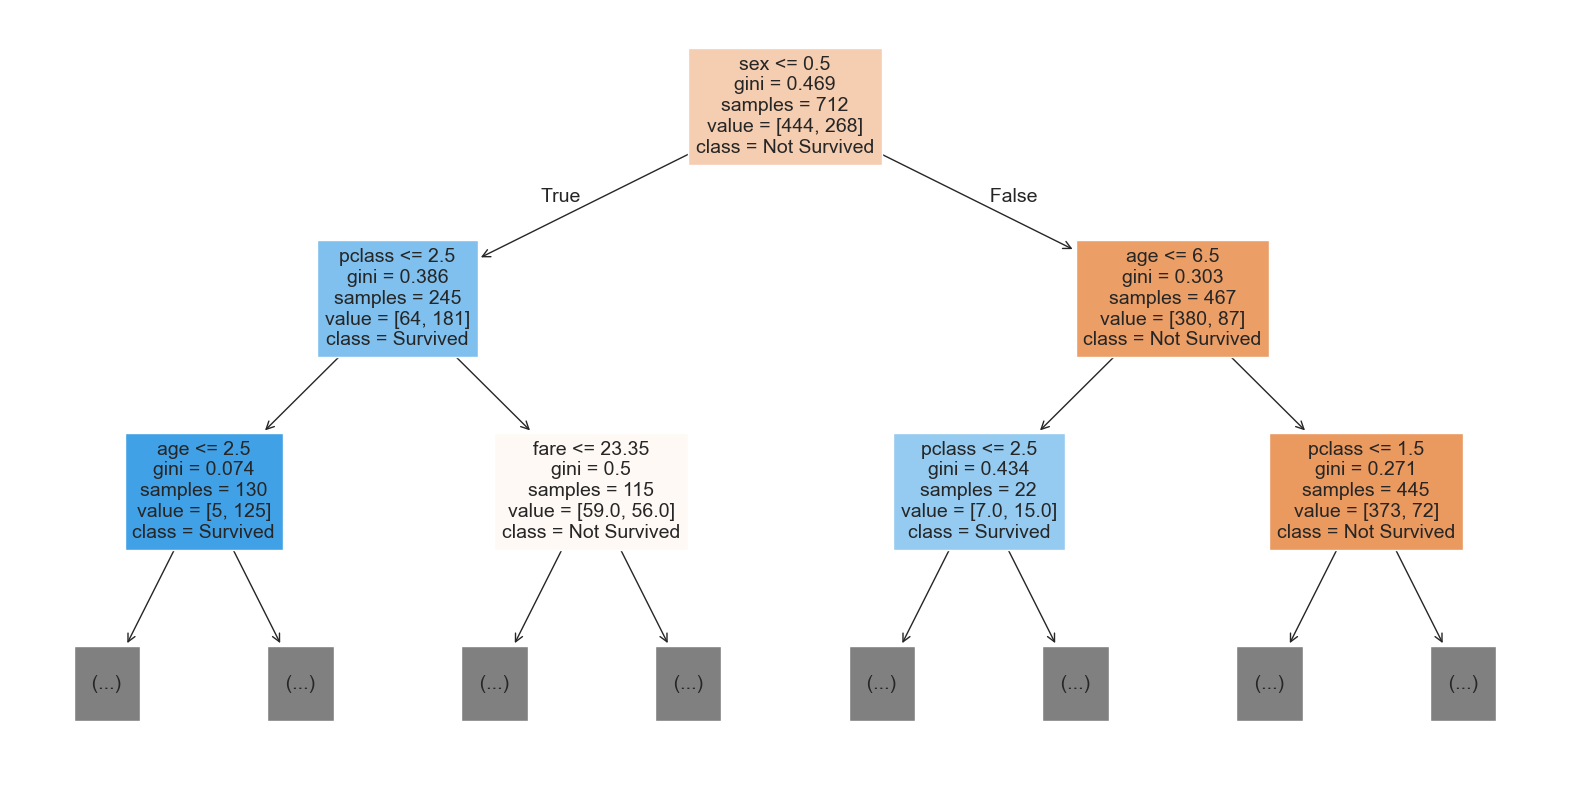

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=features, class_names=["Not Survived", "Survived"], filled=True,max_depth=2)
sns.set_style("whitegrid")


In [20]:
#decision tree with prepruning
min_samples_split = [10,15, 20,25, 30]
for i in min_samples_split:
    model_prepruning = DecisionTreeClassifier(min_samples_split=i)
    model_prepruning.fit(X_train, y_train)
    y_pred_prepruning = model_prepruning.predict(X_test)
    accuracy_prepruning = accuracy_score(y_test, y_pred_prepruning)
    print(f"Accuracy with prepruning (min_samples_split={i}):", accuracy_prepruning)

Accuracy with prepruning (min_samples_split=10): 0.8156424581005587
Accuracy with prepruning (min_samples_split=15): 0.8100558659217877
Accuracy with prepruning (min_samples_split=20): 0.8212290502793296
Accuracy with prepruning (min_samples_split=25): 0.8044692737430168
Accuracy with prepruning (min_samples_split=30): 0.7988826815642458


In [21]:
# decision_tree with postpruning
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
model_postpruning = DecisionTreeClassifier(random_state=42)
path = model_postpruning.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print("CCP Alphas:", ccp_alphas)

CCP Alphas: [0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e

In [22]:
#we can now train a series of trees with different ccp_alpha values and evaluate their performance on the test set to find the optimal level of pruning.
trees = []
for ccp_alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    tree.fit(X_train, y_train)
    trees.append((tree,ccp_alpha))


In [23]:
best_tree = 0
best_accuracy = 0
for tree, ccp_alpha in trees:
    y_pred_postpruning = tree.predict(X_test)
    accuracy_postpruning = accuracy_score(y_test, y_pred_postpruning)
    # print(f"Accuracy with postpruning (ccp_alpha={ccp_alpha}):", accuracy_postpruning)
    if accuracy_postpruning > best_accuracy:
        best_accuracy = accuracy_postpruning
        best_tree = tree
print("Best postpruning accuracy:", best_accuracy)
print("Best CCP Alpha:", best_tree.ccp_alpha)

Best postpruning accuracy: 0.8379888268156425
Best CCP Alpha: 0.0015407231242023183


In [24]:
besttree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_tree.ccp_alpha)
besttree.fit(X_train, y_train)
y_pred_besttree = besttree.predict(X_test)
accuracy_besttree = accuracy_score(y_test, y_pred_besttree)

In [27]:
#decision tree for regression
# in this we use mae or mse as the criterion for splitting the nodes, and the target variable is continuous rather than categorical. 
from sklearn.datasets import load_diabetes
data = load_diabetes(as_frame=True).frame
X = data.drop(columns=["target"])
y = data["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [28]:
from sklearn.tree import DecisionTreeRegressor
model_regressor = DecisionTreeRegressor(random_state=42)
model_regressor.fit(X_train, y_train)
y_pred_regressor = model_regressor.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error
r2 = r2_score(y_test, y_pred_regressor) 
mse = mean_squared_error(y_test, y_pred_regressor)
print("R2 Score:", r2)
print("Mean Squared Error:", mse)
#this is very bad performance, we can try to improve it by tuning the hyperparameters of the decision tree regressor, such as max_depth, min_samples_split, min_samples_leaf, etc.

R2 Score: -0.05547696148647652
Mean Squared Error: 5697.789473684211
